In [2]:
from flask import Flask, request, jsonify
from pyspark.sql import SparkSession
from pyspark.ml import PipelineModel
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
import atexit

# ============================================
# Initialize Flask App
# ============================================
app = Flask(__name__)

# ============================================
# Initialize Spark Session (Optimized Config)
# ============================================
spark = SparkSession.builder \
    .appName("KSRTC_API_Optimized") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "1g") \
    .config("spark.sql.shuffle.partitions", "2") \
    .config("spark.default.parallelism", "2") \
    .config("spark.ui.enabled", "false") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("✅ Spark session initialized with optimized settings.")

# ============================================
# Load Pre-trained Model Once at Startup
# ============================================
model_path = "D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\AI Project\\KSRTC_Project_Submission\\1.Jupyter Notebooks\\ksrtc_fare_prediction_model"
model_path = "D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\AI Project\\KSRTC_Project_Submission\\1.Jupyter Notebooks\\ksrtc_traffic_speed_model"
model = PipelineModel.load(model_path)

print(f"💾 Model loaded from: {model_path}")

# ============================================
# Define Schema for Input DataFrame
# ============================================
schema = StructType([
    StructField("Agency", StringType(), True),
    StructField("Source", StringType(), True),
    StructField("Destination", StringType(), True),
    StructField("Bus Type", StringType(), True),
    StructField("Total Seats", IntegerType(), True),
    StructField("Duration (hours)", DoubleType(), True),
    StructField("departure_hour", IntegerType(), True),
    StructField("departure_day", IntegerType(), True),
    StructField("is_peak_hour", IntegerType(), True)
])

# ============================================
# Home Page Endpoint (Prevents 404 at '/')
# ============================================
@app.route("/", methods=["GET"])
def home():
    return jsonify({"message": "KSRTC Fare Prediction API. Use /predict_fare [POST] for predictions."}), 200

# ============================================
# Prediction Endpoint
# ============================================
@app.route("/predict_fare", methods=["POST"])
def predict_fare():
    try:
        payload = request.json

        required = ["Agency", "Source", "Destination", "Bus Type", "Total Seats", "Duration"]
        missing = [f for f in required if f not in payload]
        if missing:
            return jsonify({"error": f"Missing fields: {missing}"}), 400

        input_record = {
            "Agency": str(payload["Agency"]),
            "Source": str(payload["Source"]),
            "Destination": str(payload["Destination"]),
            "Bus Type": str(payload["Bus Type"]),
            "Total Seats": int(payload["Total Seats"]),
            "Duration (hours)": float(payload["Duration"]),
            "departure_hour": int(payload.get("departure_hour", 12)),
            "departure_day": int(payload.get("departure_day", 3)),
            "is_peak_hour": int(payload.get("is_peak_hour", 0))
        }

        input_df = spark.createDataFrame([input_record], schema=schema)
        result = model.transform(input_df)
        prediction = result.select("prediction").collect()[0][0]

        return jsonify({
            "predicted_fare": round(float(prediction), 2)
        }), 200

    except Exception as e:
        return jsonify({"error": str(e)}), 500

# ============================================
# Health Check Endpoint
# ============================================
@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "OK", "spark_active": str(spark.sparkContext._jsc.sc().isStopped() == False)}), 200

# ============================================
# Graceful Spark Shutdown
# ============================================
@atexit.register
def shutdown_spark():
    spark.stop()
    print("🧠 Spark session stopped.")

# ============================================
# Run Flask Server
# ============================================
if __name__ == "__main__":
    import logging
    log = logging.getLogger('werkzeug')
    log.setLevel(logging.ERROR)

    print("🚀 KSRTC Fare Prediction API is running on http://127.0.0.1:5000/")
    app.run(host="127.0.0.1", port=5000, threaded=True)


✅ Spark session initialized with optimized settings.
💾 Model loaded from: D:\Rachith Bharadwaj T N 24BDS062\2nd Year\3rd SEM\AI Project\KSRTC_Project_Submission\1.Jupyter Notebooks\ksrtc_traffic_speed_model
🚀 KSRTC Fare Prediction API is running on http://127.0.0.1:5000/
 * Serving Flask app '__main__'
 * Debug mode: off


✅ Spark session started.
💾 Loading model from: D:\Rachith Bharadwaj T N 24BDS062\2nd Year\3rd SEM\AI Project\KSRTC_Project_Submission\1.Jupyter Notebooks\ksrtc_fare_prediction_model
📂 Loading data from: D:\Rachith Bharadwaj T N 24BDS062\2nd Year\3rd SEM\AI Project\KSRTC_Project_Submission\1.Jupyter Notebooks\cleaned_ksrtc_data.parquet
🔧 Parsing CSV string in parquet file...
✓ Columns parsed.
🧹 Cleaning data...
✓ Data cleaned. Total records: 1000
📈 Generating predictions...

--- Sample Predictions ---
+------+------------------+
|Fare  |prediction        |
+------+------------------+
|185.75|182.05532421073846|
|145.2 |148.4599152373474 |
|210.1 |198.26269949322435|
|315.8 |284.1625270192975 |
|230.45|243.2125465700505 |
+------+------------------+
only showing top 5 rows

📊 Generating visualizations...
   - Plotting Actual vs. Predicted...


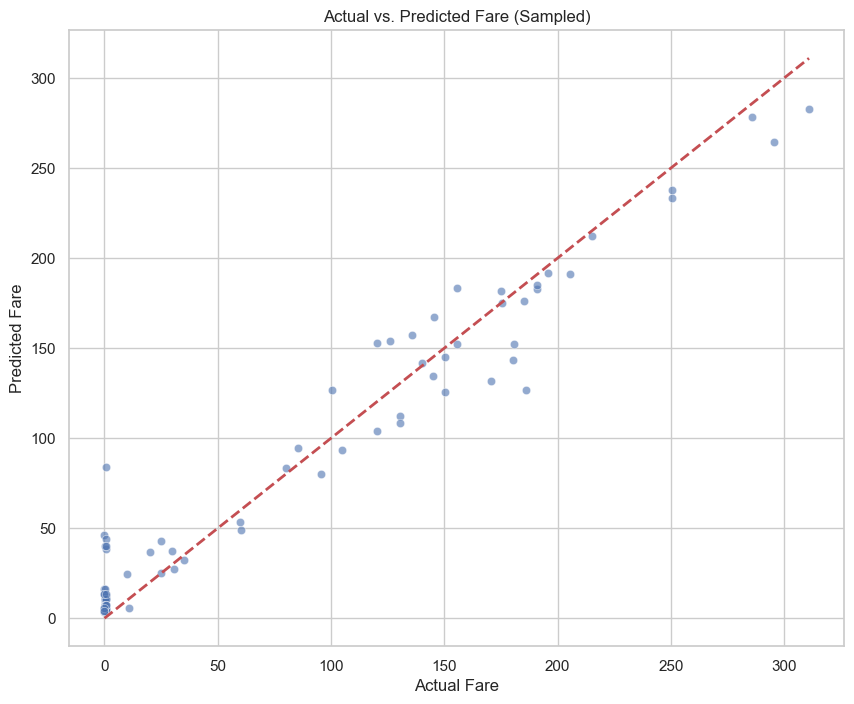

   - Plotting Feature Importance...


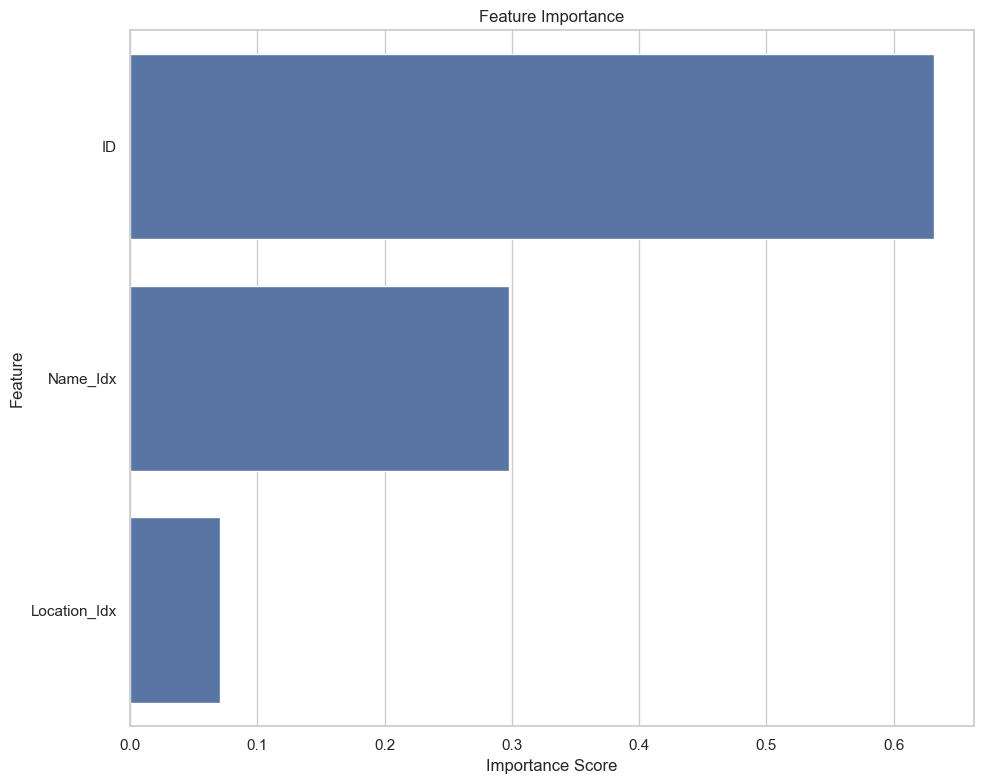


✅ Analysis Complete!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, trim
from pyspark.ml import PipelineModel
import os

# All code is now inside the main() function
def main():
    # ============================================
    # Step 1: Initialize Spark Session
    # ============================================
    spark = SparkSession.builder \
        .appName("KSRTC_Model_Analysis") \
        .getOrCreate()

    print("✅ Spark session started.")

    # ============================================
    # Step 2: Load Model and Data
    # ============================================
    model_path = "D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\AI Project\\KSRTC_Project_Submission\\1.Jupyter Notebooks\\ksrtc_fare_prediction_model"
    data_path = "D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\AI Project\\KSRTC_Project_Submission\\1.Jupyter Notebooks\\cleaned_ksrtc_data.parquet"

    print(f"💾 Loading model from: {model_path}")
    model = PipelineModel.load(model_path)

    print(f"📂 Loading data from: {data_path}")
    data = spark.read.parquet(data_path)

    # ============================================
    # Step 3: Fix the Malformed Parquet Data
    # ============================================
    print("🔧 Parsing CSV string in parquet file...")
    col_name = data.columns[0]
    data = data.withColumn("split_data", split(col(col_name), ","))

    data = data.withColumn("ID", trim(data.split_data[0])) \
               .withColumn("Name", trim(data.split_data[1])) \
               .withColumn("Location", trim(data.split_data[2])) \
               .withColumn("Date", trim(data.split_data[3])) \
               .withColumn("Arrival_Time", trim(data.split_data[4])) \
               .withColumn("Departure_Time", trim(data.split_data[5])) \
               .withColumn("Fare", trim(data.split_data[6])) \
               .withColumn("Price", trim(data.split_data[7]))

    data = data.drop(col_name, "split_data")
    print("✓ Columns parsed.")

    # ============================================
    # Step 4: Clean Data and Cast Types
    # ============================================
    print("🧹 Cleaning data...")
    target_col = "Fare"
    categorical_cols = ["Name", "Location"]
    numerical_cols = ["ID"]

    data_clean = data
    for c in [target_col] + categorical_cols + numerical_cols:
        data_clean = data_clean.filter(col(c).isNotNull())

    # Cast types so the model can use them
    data_clean = data_clean.withColumn(target_col, col(target_col).cast("double"))
    for c in numerical_cols:
        data_clean = data_clean.withColumn(c, col(c).cast("double"))

    print(f"✓ Data cleaned. Total records: {data_clean.count()}")

    # ============================================
    # Step 5: Get Predictions
    # ============================================
    print("📈 Generating predictions...")
    # Use the model to predict on the *entire* dataset
    predictions = model.transform(data_clean)

    print("\n--- Sample Predictions ---")
    predictions.select(target_col, "prediction").show(5, truncate=False)

    # ============================================
    # Step 6: 📊 Visualize Model Results
    # ============================================
    print("\n📊 Generating visualizations...")
    sns.set_theme(style="whitegrid")

    # --- Plot 1: Actual vs. Predicted Scatter Plot ---
    try:
        print("   - Plotting Actual vs. Predicted...")
        pred_sample_pd = predictions.select(target_col, "prediction") \
                                    .sample(withReplacement=False, fraction=0.1, seed=42) \
                                    .limit(1000) \
                                    .toPandas()

        plt.figure(figsize=(10, 8))
        sns.scatterplot(data=pred_sample_pd, x=target_col, y="prediction", alpha=0.6)
        
        min_val = min(pred_sample_pd[target_col].min(), pred_sample_pd["prediction"].min())
        max_val = max(pred_sample_pd[target_col].max(), pred_sample_pd["prediction"].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
        
        plt.title("Actual vs. Predicted Fare (Sampled)")
        plt.xlabel("Actual Fare")
        plt.ylabel("Predicted Fare")
        plt.show()

    except Exception as e:
        print(f"   ⚠️ Could not plot Actual vs. Predicted: {e}")

    # --- Plot 2: Feature Importance Bar Plot ---
    try:
        print("   - Plotting Feature Importance...")
        feature_cols = model.stages[-2].getInputCols()
        rf_model = model.stages[-1]
        importances = rf_model.featureImportances.toArray()
        
        imp_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': importances
        }).sort_values(by='importance', ascending=False)
        
        plt.figure(figsize=(10, 8))
        sns.barplot(data=imp_df, x='importance', y='feature', orient='h')
        plt.title("Feature Importance")
        plt.xlabel("Importance Score")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"   ⚠️ Could not plot Feature Importance: {e}")

    # ============================================
    # Step 7: Stop Spark
    # ============================================
    spark.stop()
    print("\n✅ Analysis Complete!")

# This part now correctly calls the function defined above
if __name__ == "__main__":
    main()
